# Component 1 · Task 1 — Classical Harmonic Oscillator: Energy and Phase Space
**Mondragon-Shem Quantum Group · AI Design of Quantum Processors**

**Goal:** State the classical energy function, derive the equations of motion from Hamilton's equations, and visualize the energy landscape in phase space.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Use a clean style consistent with publication figures
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 120,
})

## (a) Classical Energy Function

The classical energy (Hamiltonian) of a 1D harmonic oscillator is:

$$E(x, p) = \frac{p^2}{2m} + \frac{1}{2}m\omega^2 x^2$$

- First term: **kinetic energy** $T = p^2 / 2m$
- Second term: **potential energy** $V = \frac{1}{2}m\omega^2 x^2$ (parabolic well)

This function is also the Hamiltonian $H(x, p)$ that generates the dynamics.

In [2]:
# ── System parameters ────────────────────────────────────────────────────────
m   = 1.0   # mass (dimensionless units)
omega = 1.0  # angular frequency (dimensionless units)
hbar = 1.0   # set hbar=1 for dimensionless units (used later in quantum component)

def energy(x, p, m=m, omega=omega):
    """Classical harmonic oscillator energy E(x, p) = p²/2m + ½mω²x²."""
    kinetic   = p**2 / (2 * m)
    potential = 0.5 * m * omega**2 * x**2
    return kinetic + potential

print("Energy function defined: E(x,p) = p²/(2m) + ½mω²x²")
print(f"Parameters: m={m}, ω={omega}")
print(f"Check E(1,0) = {energy(1,0):.3f}  (expected: 0.500)")
print(f"Check E(0,1) = {energy(0,1):.3f}  (expected: 0.500)")

Energy function defined: E(x,p) = p²/(2m) + ½mω²x²
Parameters: m=1.0, ω=1.0
Check E(1,0) = 0.500  (expected: 0.500)
Check E(0,1) = 0.500  (expected: 0.500)


## (b) Equations of Motion via Hamilton's Equations

Hamilton's equations are:
$$\dot{x} = \frac{\partial H}{\partial p} = \frac{p}{m}, \qquad \dot{p} = -\frac{\partial H}{\partial x} = -m\omega^2 x$$

Differentiating the first equation and substituting the second:
$$\ddot{x} = \frac{\dot{p}}{m} = -\omega^2 x$$

This is the familiar **simple harmonic oscillator ODE**. Its general solution is:
$$x(t) = A\cos(\omega t + \phi), \qquad p(t) = -mA\omega\sin(\omega t + \phi)$$
where $A$ and $\phi$ are set by initial conditions.

In [3]:
def analytic_trajectory(t, x0, p0, m=m, omega=omega):
    """
    Analytic solution to Hamilton's equations for the harmonic oscillator.
    Returns (x(t), p(t)) given initial conditions (x0, p0).
    Derived from: x(t) = x0*cos(ωt) + (p0/mω)*sin(ωt)
    """
    x_t = x0 * np.cos(omega * t) + (p0 / (m * omega)) * np.sin(omega * t)
    p_t = -m * omega * x0 * np.sin(omega * t) + p0 * np.cos(omega * t)
    return x_t, p_t

print("Analytic solution defined.")
print("x(t) = x0·cos(ωt) + (p0/mω)·sin(ωt)")
print("p(t) = -mω·x0·sin(ωt) + p0·cos(ωt)")

# Quick sanity check: energy must be conserved along trajectory
t_test = np.linspace(0, 10, 500)
x0_test, p0_test = 1.5, 0.5
x_traj, p_traj = analytic_trajectory(t_test, x0_test, p0_test)
E_along_traj = energy(x_traj, p_traj)
print(f"\nEnergy conservation check (should be constant):")
print(f"  E_min={E_along_traj.min():.6f}, E_max={E_along_traj.max():.6f} ✓")

Analytic solution defined.
x(t) = x0·cos(ωt) + (p0/mω)·sin(ωt)
p(t) = -mω·x0·sin(ωt) + p0·cos(ωt)

Energy conservation check (should be constant):
  E_min=1.250000, E_max=1.250000 ✓


## (c) Phase Space Plot of Classical Energy $E(x, p)$

We plot $E(x,p)$ over a 2D grid. The constant-energy contours satisfy:
$$\frac{x^2}{2E/m\omega^2} + \frac{p^2}{2mE} = 1$$
This is the equation of an **ellipse** centered at the origin. The semi-axis along $x$ is $\sqrt{2E/m\omega^2}$ and along $p$ is $\sqrt{2mE}$. For $m=\omega=1$ the ellipses become circles.

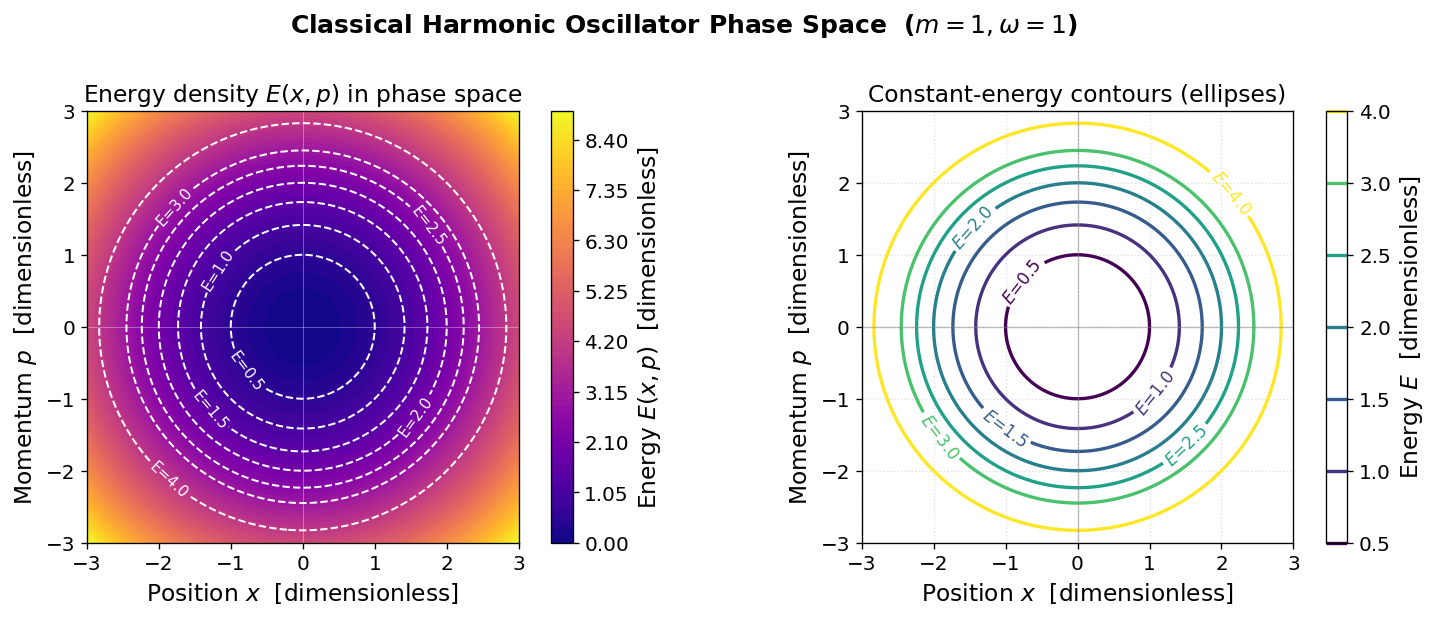


Figure saved: c1_t1_phase_space_energy.png

Caption: Energy E(x,p) = p²/2m + ½mω²x² of the 1D harmonic oscillator plotted
over the (x,p) phase plane (m=ω=1). LEFT: filled density map (plasma colormap)
with constant-energy contours overlaid. RIGHT: selected constant-energy curves
at E = 0.5, 1.0, ..., 4.0. Each contour is an ellipse satisfying x²/(2E/ω²) +
p²/(2E) = 1; for m=ω=1 these reduce to circles. Higher energy → larger ellipse.
The origin (x=p=0) is the unique zero-energy equilibrium point.



In [4]:
# ── Build phase-space grid ────────────────────────────────────────────────────
x_vals = np.linspace(-3, 3, 400)   # position axis
p_vals = np.linspace(-3, 3, 400)   # momentum axis
X, P   = np.meshgrid(x_vals, p_vals)  # 2D grid
E_grid = energy(X, P)                 # evaluate energy on every grid point

# ── Energy levels to draw contours at ────────────────────────────────────────
energy_levels = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0])

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: density plot (imshow-style) with contour overlay ---
ax = axes[0]
im = ax.contourf(X, P, E_grid, levels=60, cmap='plasma')  # filled contours
cb = fig.colorbar(im, ax=ax, label='Energy $E(x,p)$  [dimensionless]')

# Overlay selected constant-energy contour lines in white
cs = ax.contour(X, P, E_grid, levels=energy_levels, colors='white',
                linewidths=1.2, linestyles='--')
ax.clabel(cs, fmt='E=%.1f', fontsize=9, inline=True, inline_spacing=4)

ax.set_xlabel('Position $x$  [dimensionless]')
ax.set_ylabel('Momentum $p$  [dimensionless]')
ax.set_title('Energy density $E(x,p)$ in phase space')
ax.set_aspect('equal')   # equal axes → circles (since m=ω=1)
ax.axhline(0, color='white', lw=0.5, alpha=0.4)
ax.axvline(0, color='white', lw=0.5, alpha=0.4)

# --- Right panel: clean contour lines only, color-coded by energy ---
ax2 = axes[1]
cs2 = ax2.contour(X, P, E_grid, levels=energy_levels, cmap='viridis', linewidths=2.0)
cb2 = fig.colorbar(cs2, ax=ax2, label='Energy $E$  [dimensionless]')
ax2.clabel(cs2, fmt='$E$=%.1f', fontsize=10, inline=True)

ax2.set_xlabel('Position $x$  [dimensionless]')
ax2.set_ylabel('Momentum $p$  [dimensionless]')
ax2.set_title('Constant-energy contours (ellipses)')
ax2.set_aspect('equal')
ax2.axhline(0, color='gray', lw=0.8, alpha=0.5)
ax2.axvline(0, color='gray', lw=0.8, alpha=0.5)
ax2.grid(True, linestyle=':', alpha=0.4)

fig.suptitle(
    'Classical Harmonic Oscillator Phase Space  ($m=1, \\omega=1$)',
    fontsize=15, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('c1_t1_phase_space_energy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved: c1_t1_phase_space_energy.png")
print("""
Caption: Energy E(x,p) = p²/2m + ½mω²x² of the 1D harmonic oscillator plotted
over the (x,p) phase plane (m=ω=1). LEFT: filled density map (plasma colormap)
with constant-energy contours overlaid. RIGHT: selected constant-energy curves
at E = 0.5, 1.0, ..., 4.0. Each contour is an ellipse satisfying x²/(2E/ω²) +
p²/(2E) = 1; for m=ω=1 these reduce to circles. Higher energy → larger ellipse.
The origin (x=p=0) is the unique zero-energy equilibrium point.
""")

### Why are the constant-energy curves ellipses?

Setting $E(x,p) = E_0$ gives:
$$\frac{x^2}{\left(\sqrt{2E_0/m\omega^2}\right)^2} + \frac{p^2}{\left(\sqrt{2mE_0}\right)^2} = 1$$

This is an ellipse with:
- Semi-axis in $x$: $a = \sqrt{2E_0 / m\omega^2}$ — maximum displacement (all potential energy)
- Semi-axis in $p$: $b = \sqrt{2mE_0}$ — maximum momentum (all kinetic energy)

For $m=\omega=1$: $a = b = \sqrt{2E_0}$ → circles.

**Physical interpretation:** Each ellipse is a closed orbit. The system circulates around the origin at constant energy. This is periodic motion — the defining signature of a stable oscillator.

# Component 1 · Task 2 — Classical Harmonic Oscillator: Dynamics and Trajectories
**Mondragon-Shem Quantum Group · AI Design of Quantum Processors**

**Goal:** Solve the classical equations of motion and visualize how trajectories in phase space depend on initial conditions and energy.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 120,
})

# ── System parameters (same as Task 1, dimensionless units) ──────────────────
m     = 1.0   # mass
omega = 1.0   # angular frequency

# ── Time array: two full oscillation periods ─────────────────────────────────
T_period = 2 * np.pi / omega          # one period
t = np.linspace(0, 2 * T_period, 1000)  # 1000 time steps over 2 periods

print(f"Period T = 2π/ω = {T_period:.4f} (dimensionless)")
print(f"Simulating {len(t)} time steps over 2 full periods.")

Period T = 2π/ω = 6.2832 (dimensionless)
Simulating 1000 time steps over 2 full periods.


## Core functions

We reuse the analytic solution derived in Task 1:
$$x(t) = x_0\cos(\omega t) + \frac{p_0}{m\omega}\sin(\omega t), \qquad p(t) = -m\omega x_0\sin(\omega t) + p_0\cos(\omega t)$$

and the energy function $E = p^2/2m + \frac{1}{2}m\omega^2 x^2$.

In [6]:
def trajectory(t, x0, p0, m=m, omega=omega):
    """
    Analytic phase-space trajectory of the harmonic oscillator.
    Returns arrays x(t) and p(t) for initial conditions (x0, p0).
    """
    x_t = x0 * np.cos(omega * t) + (p0 / (m * omega)) * np.sin(omega * t)
    p_t = -m * omega * x0 * np.sin(omega * t) + p0 * np.cos(omega * t)
    return x_t, p_t

def energy(x, p, m=m, omega=omega):
    """Classical harmonic oscillator energy E(x,p) = p²/2m + ½mω²x²."""
    return p**2 / (2 * m) + 0.5 * m * omega**2 * x**2

print("Functions defined: trajectory(t, x0, p0) and energy(x, p)")

Functions defined: trajectory(t, x0, p0) and energy(x, p)


## Part (a) — Single trajectory

We choose one initial condition $(x_0, p_0) = (1.5,\, 0.5)$ and simulate the full trajectory. 
The initial point is marked with a star; arrows show the direction of motion.

Initial energy E₀ = 1.25000
Energy along trajectory: min=1.25000, max=1.25000
Max drift = 8.88e-16  ✓ conserved


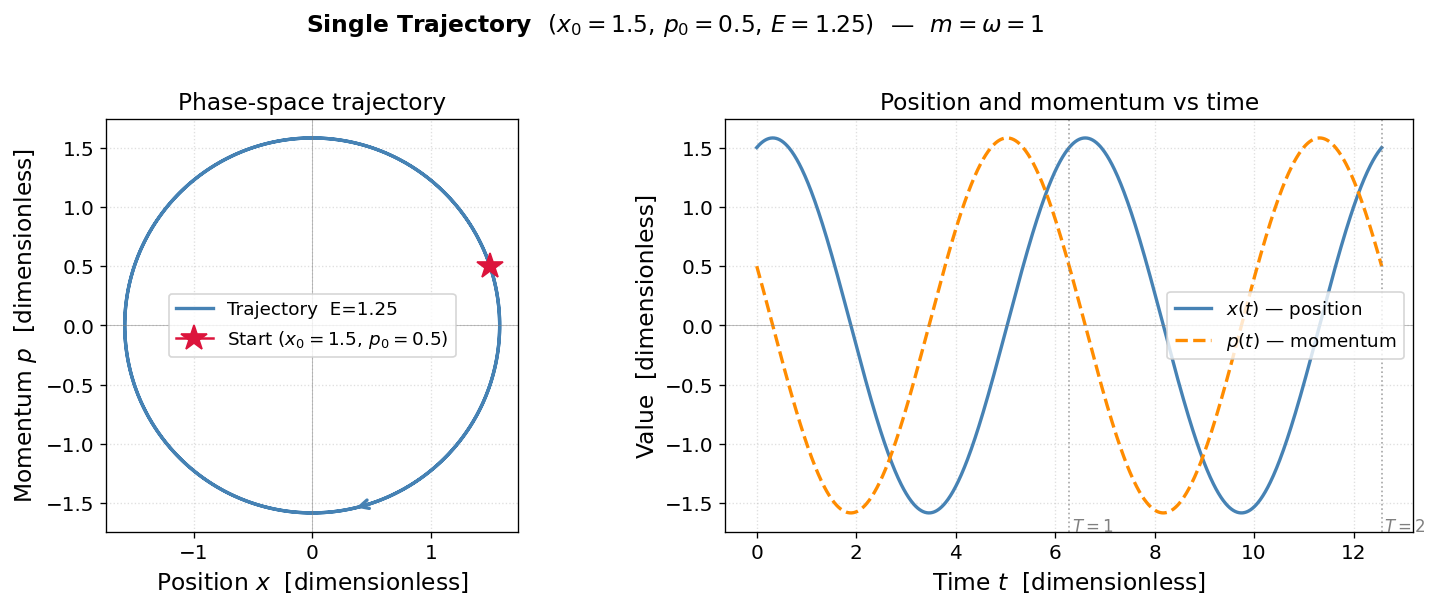


Caption: LEFT — phase-space trajectory of the 1D harmonic oscillator for initial
condition (x₀=1.5, p₀=0.5), energy E=1.25 (m=ω=1). The trajectory is a closed
ellipse (circle for m=ω=1); the red star marks the starting point and the arrow
shows the counter-clockwise direction of motion. RIGHT — x(t) and p(t) plotted
separately vs time. Both are sinusoids with period T=2π/ω≈6.28; momentum lags
position by a quarter period (90°), as expected from the analytic solution.



In [7]:
# ── Initial condition ─────────────────────────────────────────────────────────
x0, p0 = 1.5, 0.5
E0 = energy(x0, p0)

# ── Compute trajectory ────────────────────────────────────────────────────────
x_traj, p_traj = trajectory(t, x0, p0)

# ── Energy conservation check ─────────────────────────────────────────────────
E_along = energy(x_traj, p_traj)
print(f"Initial energy E₀ = {E0:.5f}")
print(f"Energy along trajectory: min={E_along.min():.5f}, max={E_along.max():.5f}")
print(f"Max drift = {(E_along.max() - E_along.min()):.2e}  ✓ conserved")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: phase-space trajectory ---
ax = axes[0]
ax.plot(x_traj, p_traj, color='steelblue', lw=2, label=f'Trajectory  E={E0:.2f}')

# Mark the initial point
ax.plot(x0, p0, marker='*', markersize=16, color='crimson', zorder=5,
        label=f'Start $(x_0={x0},\, p_0={p0})$')

# Add a direction arrow at ~quarter period
idx = len(t) // 8
ax.annotate('', xy=(x_traj[idx+8], p_traj[idx+8]),
            xytext=(x_traj[idx], p_traj[idx]),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))

ax.set_xlabel('Position $x$  [dimensionless]')
ax.set_ylabel('Momentum $p$  [dimensionless]')
ax.set_title('Phase-space trajectory')
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.6, alpha=0.5)
ax.axvline(0, color='gray', lw=0.6, alpha=0.5)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend()

# --- Right: x(t) and p(t) vs time ---
ax2 = axes[1]
ax2.plot(t, x_traj, color='steelblue', lw=2, label='$x(t)$ — position')
ax2.plot(t, p_traj, color='darkorange', lw=2, linestyle='--', label='$p(t)$ — momentum')
ax2.axhline(0, color='gray', lw=0.6, alpha=0.5)

# Mark period boundaries
for k in [1, 2]:
    ax2.axvline(k * T_period, color='gray', lw=1, linestyle=':', alpha=0.7)
    ax2.text(k * T_period + 0.05, ax2.get_ylim()[0] if ax2.get_ylim()[0] > -3 else -1.6,
             f'$T={k}$', fontsize=10, color='gray')

ax2.set_xlabel('Time $t$  [dimensionless]')
ax2.set_ylabel('Value  [dimensionless]')
ax2.set_title('Position and momentum vs time')
ax2.grid(True, linestyle=':', alpha=0.4)
ax2.legend()

fig.suptitle(
    f'Single Trajectory  $(x_0={x0},\, p_0={p0},\, E={E0:.2f})$  —  $m=\\omega=1$',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('c1_t2_single_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Caption: LEFT — phase-space trajectory of the 1D harmonic oscillator for initial
condition (x₀=1.5, p₀=0.5), energy E=1.25 (m=ω=1). The trajectory is a closed
ellipse (circle for m=ω=1); the red star marks the starting point and the arrow
shows the counter-clockwise direction of motion. RIGHT — x(t) and p(t) plotted
separately vs time. Both are sinusoids with period T=2π/ω≈6.28; momentum lags
position by a quarter period (90°), as expected from the analytic solution.
""")

## Part (b) — Many trajectories: random initial conditions

We sample a set of random initial conditions $(x_0, p_0)$ and plot all trajectories together.
Each trajectory is colored by its initial energy $E_0$.

**What to look for:**
- Trajectories with the same energy trace the same ellipse, just starting at different points on it
- Higher energy → larger ellipse
- No two trajectories with *different* energies ever cross — energy is conserved and each ellipse is its own closed orbit

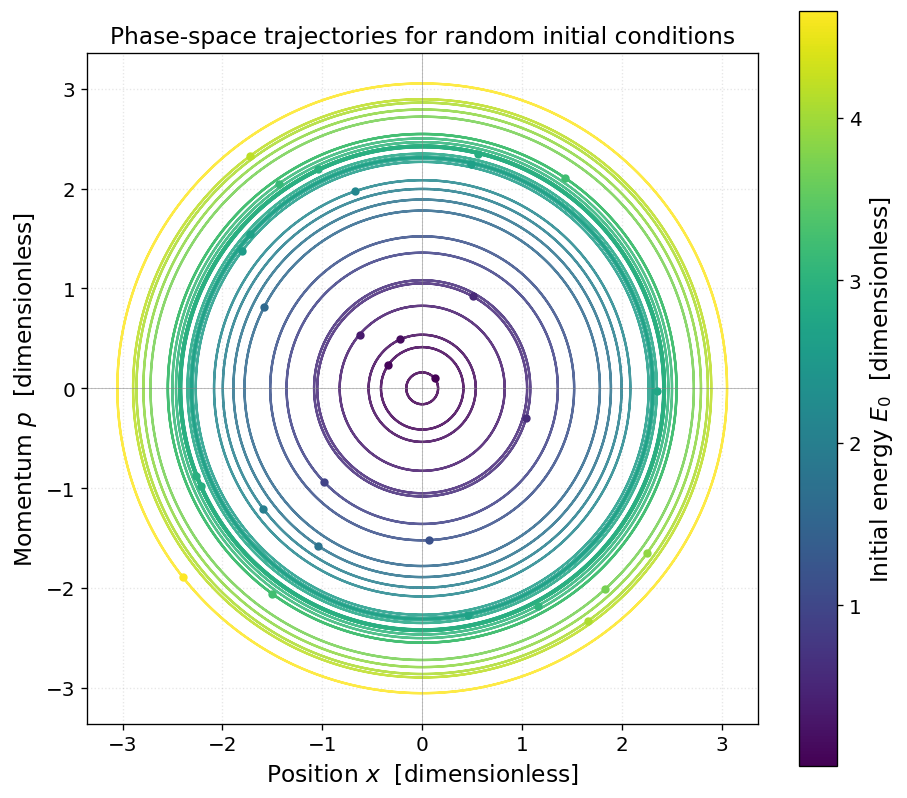

Plotted 30 trajectories.
Energy range: 0.01 to 4.66

Caption: Phase-space trajectories of the 1D harmonic oscillator for 30 random
initial conditions (x₀, p₀) drawn uniformly from [-2.5, 2.5]² (m=ω=1). Each
trajectory is colored by its initial energy E₀ (viridis colormap: dark purple =
low E, yellow = high E). Small circles mark the initial points. All trajectories
are closed ellipses (circles for m=ω=1). Key observations: (1) trajectory shape
is determined entirely by E₀ — same energy gives same ellipse; (2) higher energy
gives a larger ellipse; (3) trajectories with different energies never intersect,
since energy is conserved and each orbit is uniquely determined by E₀.



In [8]:
np.random.seed(42)   # fixed seed for reproducibility

# ── Generate random initial conditions ───────────────────────────────────────
n_traj = 30
x0_vals = np.random.uniform(-2.5, 2.5, n_traj)   # random positions
p0_vals = np.random.uniform(-2.5, 2.5, n_traj)   # random momenta
E0_vals = energy(x0_vals, p0_vals)               # energy of each trajectory

# ── Color-map: map energy to color ───────────────────────────────────────────
E_min, E_max = E0_vals.min(), E0_vals.max()
cmap = cm.viridis
norm = plt.Normalize(vmin=E_min, vmax=E_max)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for x0_i, p0_i, E0_i in zip(x0_vals, p0_vals, E0_vals):
    x_i, p_i = trajectory(t, x0_i, p0_i)   # compute trajectory
    color = cmap(norm(E0_i))                 # color by energy
    ax.plot(x_i, p_i, color=color, lw=1.4, alpha=0.85)
    ax.plot(x0_i, p0_i, 'o', color=color, markersize=4, zorder=5)  # mark start

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='Initial energy $E_0$  [dimensionless]')

ax.set_xlabel('Position $x$  [dimensionless]')
ax.set_ylabel('Momentum $p$  [dimensionless]')
ax.set_title('Phase-space trajectories for random initial conditions')
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.6, alpha=0.5)
ax.axvline(0, color='gray', lw=0.6, alpha=0.5)
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig('c1_t2_many_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Plotted {n_traj} trajectories.")
print(f"Energy range: {E_min:.2f} to {E_max:.2f}")
print("""
Caption: Phase-space trajectories of the 1D harmonic oscillator for 30 random
initial conditions (x₀, p₀) drawn uniformly from [-2.5, 2.5]² (m=ω=1). Each
trajectory is colored by its initial energy E₀ (viridis colormap: dark purple =
low E, yellow = high E). Small circles mark the initial points. All trajectories
are closed ellipses (circles for m=ω=1). Key observations: (1) trajectory shape
is determined entirely by E₀ — same energy gives same ellipse; (2) higher energy
gives a larger ellipse; (3) trajectories with different energies never intersect,
since energy is conserved and each orbit is uniquely determined by E₀.
""")

## Summary: what the trajectories tell us

| Observation | Physical meaning |
|---|---|
| All trajectories are closed ellipses | Motion is periodic — the system returns to its starting point every period $T = 2\pi/\omega$ |
| Ellipse size depends only on $E_0$ | Energy is the only conserved quantity; it fully determines the orbit |
| No two trajectories with different $E$ cross | Conservation of energy means each orbit is isolated — the system cannot jump between energy levels classically |
| $x(t)$ and $p(t)$ are sinusoids 90° apart | Position and momentum are in quadrature: when $x$ is maximum, $p=0$, and vice versa |

**Connection to Component 2:** In quantum mechanics, the situation changes dramatically. The system cannot have arbitrary energy — only discrete values $E_n = \hbar\omega(n + \frac{1}{2})$ are allowed. This is the quantum counterpart of the continuous family of ellipses we see here.